# Project V — Advanced Clustering Readiness and Feature Audit

This notebook defines and audits the parent sample and feature spaces for
advanced unsupervised discovery.

## Scientific purpose

The objective is to prepare a statistically defensible input catalogue for
HDBSCAN, OPTICS, Gaussian Mixture Models, and later consensus clustering.

The previously identified 27 chemo-kinematic candidates are retained only as
an external recovery set. They are not used to fit models or select parameters.


In [1]:
from pathlib import Path
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.cluster import HDBSCAN, OPTICS
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import RobustScaler

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

sns.set_theme(style="whitegrid", context="notebook")

print("Python:", platform.python_version())
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("HDBSCAN:", HDBSCAN)
print("OPTICS:", OPTICS)
print("GaussianMixture:", GaussianMixture)


Python: 3.12.7
pandas: 2.2.2
scikit-learn: 1.9.0
HDBSCAN: <class 'sklearn.cluster._hdbscan.hdbscan.HDBSCAN'>
OPTICS: <class 'sklearn.cluster._optics.OPTICS'>
GaussianMixture: <class 'sklearn.mixture._gaussian_mixture.GaussianMixture'>


## 1. Load the discovery parent sample

The larger Gaia–LAMOST feature table is used as the discovery parent sample.
The 27-row cross-method table is loaded only for external candidate recovery
checks.


In [2]:
parent_path = Path(
    "data/processed/gaia_lamost_larger_chemo_kinematic_features.csv"
)
candidate_path = Path(
    "data/processed/project2_candidate_cross_method_summary.csv"
)

parent = pd.read_csv(parent_path)
known_candidates = pd.read_csv(candidate_path)

core_features = [
    "feh",
    "rv",
    "tangential_velocity_kms",
    "bp_rp",
    "absolute_g_mag",
]

extended_features = core_features + [
    "teff",
    "logg",
]

flag_columns = [
    "metal_poor_candidate",
    "high_vtan_candidate",
    "chemo_kinematic_candidate",
]

print("Parent shape:", parent.shape)
print("Unique source IDs:", parent["source_id"].nunique())
print("Known candidates:", len(known_candidates))


Parent shape: (1838, 38)
Unique source IDs: 1838
Known candidates: 27


## 2. Catalogue-integrity audit

In [3]:
parent_ids = set(parent["source_id"].astype(str))
candidate_ids = set(known_candidates["source_id"].astype(str))
overlap_ids = parent_ids & candidate_ids

integrity_summary = pd.DataFrame(
    [
        {
            "metric": "parent_rows",
            "value": len(parent),
        },
        {
            "metric": "unique_parent_source_ids",
            "value": parent["source_id"].nunique(),
        },
        {
            "metric": "duplicate_parent_source_ids",
            "value": parent["source_id"].duplicated().sum(),
        },
        {
            "metric": "known_candidate_rows",
            "value": len(known_candidates),
        },
        {
            "metric": "known_candidates_found_in_parent",
            "value": len(overlap_ids),
        },
        {
            "metric": "known_candidates_missing_from_parent",
            "value": len(candidate_ids - parent_ids),
        },
        {
            "metric": "core_complete_rows",
            "value": parent[core_features].notna().all(axis=1).sum(),
        },
        {
            "metric": "extended_complete_rows",
            "value": parent[extended_features].notna().all(axis=1).sum(),
        },
    ]
)

integrity_summary


,metric,value
0,parent_rows,1838
1,unique_parent_source_ids,1838
2,duplicate_parent_source_ids,0
3,known_candidate_rows,27
4,known_candidates_found_in_parent,27
5,known_candidates_missing_from_parent,0
6,core_complete_rows,1838
7,extended_complete_rows,1838


## 3. Feature-level audit

In [4]:
quantile_levels = [0.00, 0.01, 0.05, 0.50, 0.95, 0.99, 1.00]

feature_rows = []

for feature_set_name, feature_names in [
    ("core", core_features),
    ("extended_only", ["teff", "logg"]),
]:
    for feature in feature_names:
        series = parent[feature]
        quantiles = series.quantile(quantile_levels)

        feature_rows.append(
            {
                "feature_set": feature_set_name,
                "feature": feature,
                "dtype": str(series.dtype),
                "row_count": len(series),
                "complete_count": int(series.notna().sum()),
                "missing_count": int(series.isna().sum()),
                "missing_fraction": float(series.isna().mean()),
                "unique_count": int(series.nunique(dropna=True)),
                "mean": float(series.mean()),
                "std": float(series.std()),
                "minimum": float(quantiles.loc[0.00]),
                "q01": float(quantiles.loc[0.01]),
                "q05": float(quantiles.loc[0.05]),
                "median": float(quantiles.loc[0.50]),
                "q95": float(quantiles.loc[0.95]),
                "q99": float(quantiles.loc[0.99]),
                "maximum": float(quantiles.loc[1.00]),
                "recommended_scaling": "RobustScaler",
                "preclipping": False,
                "clustering_role": (
                    "primary"
                    if feature_set_name == "core"
                    else "sensitivity analysis"
                ),
            }
        )

feature_audit = pd.DataFrame(feature_rows)
feature_audit


,feature_set,feature,dtype,row_count,complete_count,missing_count,missing_fraction,unique_count,mean,std,minimum,q01,q05,median,q95,q99,maximum,recommended_scaling,preclipping,clustering_role
0,core,feh,float64,1838,1838,0,0.0,823,-0.155585,0.270375,-2.213000,-0.881520,-0.565150,-0.133000,0.230150,0.364630,0.581000,RobustScaler,False,primary
1,core,rv,float64,1838,1838,0,0.0,1718,29.674434,36.549222,-76.140000,-44.292300,-23.442500,27.875000,86.705000,122.811600,385.540000,RobustScaler,False,primary
2,core,tangential_velocity_kms,float64,1838,1838,0,0.0,1838,37.420261,30.688631,1.275461,3.021501,8.799689,32.391688,73.452011,156.236891,426.686109,RobustScaler,False,primary
3,core,bp_rp,float64,1838,1838,0,0.0,1833,0.895736,0.258662,0.202945,0.521733,0.573444,0.820465,1.358390,1.535523,1.684119,RobustScaler,False,primary
4,core,absolute_g_mag,float64,1838,1838,0,0.0,1838,3.140754,1.683187,-2.438673,-0.734069,0.295578,3.340111,5.797896,6.855568,7.546804,RobustScaler,False,primary
5,extended_only,teff,float64,1838,1838,0,0.0,1822,5666.280136,715.637180,4035.120000,4198.911400,4473.846000,5780.365000,6703.747000,6902.171600,6996.330000,RobustScaler,False,sensitivity analysis
6,extended_only,logg,float64,1838,1838,0,0.0,1067,3.846653,0.723926,0.837000,1.966680,2.375700,4.128000,4.628150,4.730630,4.839000,RobustScaler,False,sensitivity analysis


## 4. Correlation and distribution diagnostics

Raw feature distributions are intentionally retained. Strong tails are
documented but not removed because unusual kinematics and metallicity are part
of the discovery target.


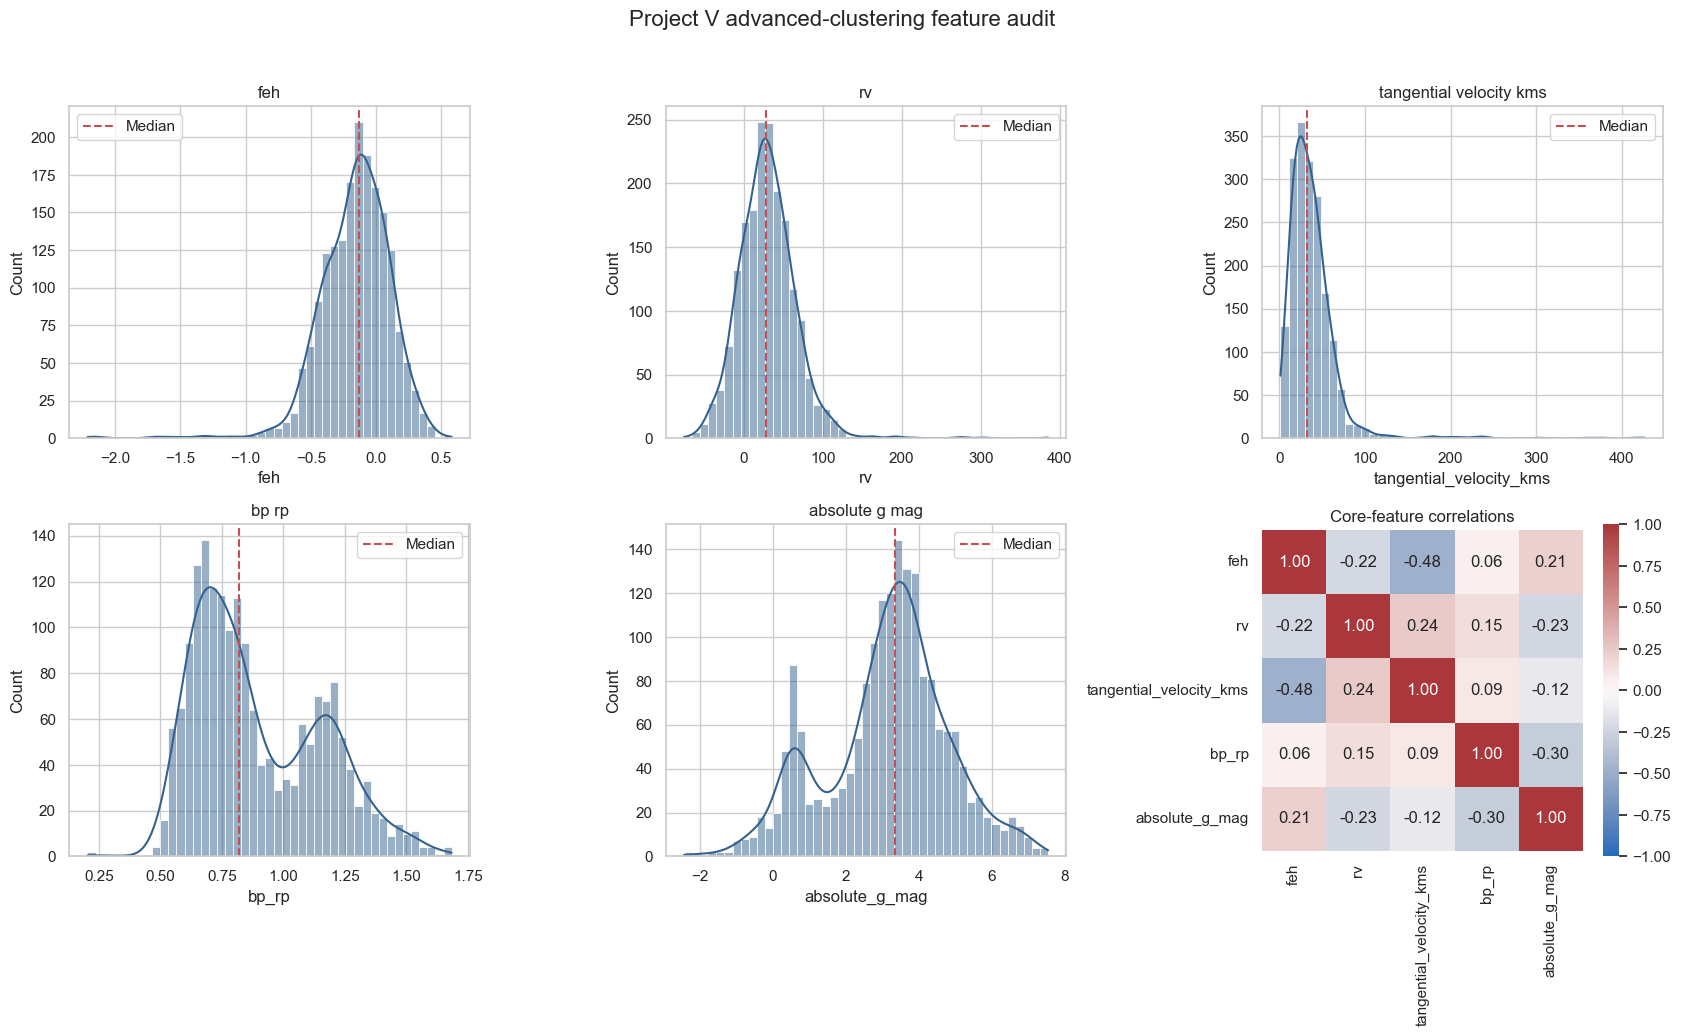

In [5]:
core_correlations = parent[core_features].corr()

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
axes = axes.ravel()

for axis, feature in zip(axes[:5], core_features):
    sns.histplot(
        data=parent,
        x=feature,
        bins=45,
        kde=True,
        color="#35618f",
        ax=axis,
    )
    axis.axvline(
        parent[feature].median(),
        color="#c44e52",
        linestyle="--",
        linewidth=1.5,
        label="Median",
    )
    axis.set_title(feature.replace("_", " "))
    axis.legend()

sns.heatmap(
    core_correlations,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    ax=axes[5],
)
axes[5].set_title("Core-feature correlations")

fig.suptitle(
    "Project V advanced-clustering feature audit",
    fontsize=16,
    y=1.02,
)
fig.tight_layout()


## 5. Robust-scaling readiness

In [6]:
scaler = RobustScaler()
core_scaled = scaler.fit_transform(parent[core_features])
extended_scaled = scaler.fit_transform(parent[extended_features])

scaling_summary = pd.DataFrame(
    {
        "feature": core_features,
        "scaled_median": np.median(core_scaled, axis=0),
        "scaled_q25": np.quantile(core_scaled, 0.25, axis=0),
        "scaled_q75": np.quantile(core_scaled, 0.75, axis=0),
        "scaled_iqr": (
            np.quantile(core_scaled, 0.75, axis=0)
            - np.quantile(core_scaled, 0.25, axis=0)
        ),
    }
)

print("Core scaled matrix:", core_scaled.shape)
print("Extended scaled matrix:", extended_scaled.shape)
scaling_summary


Core scaled matrix: (1838, 5)
Extended scaled matrix: (1838, 7)


,feature,scaled_median,scaled_q25,scaled_q75,scaled_iqr
0,feh,0.000000e+00,-0.540299,0.459701,1.0
1,rv,0.000000e+00,-0.502267,0.497733,1.0
2,tangential_velocity_kms,-1.356608e-16,-0.458116,0.541884,1.0
3,bp_rp,0.000000e+00,-0.305346,0.694654,1.0
4,absolute_g_mag,0.000000e+00,-0.558149,0.441851,1.0


## 6. Known-candidate recovery control

In [7]:
overlap = parent[
    parent["source_id"].astype(str).isin(overlap_ids)
].copy()

candidate_recovery_summary = pd.DataFrame(
    [
        {
            "metric": "known_candidate_overlap_rows",
            "value": len(overlap),
        },
        *[
            {
                "metric": f"{column}_positive_in_overlap",
                "value": int(overlap[column].sum()),
            }
            for column in flag_columns
        ],
    ]
)

candidate_recovery_summary


,metric,value
0,known_candidate_overlap_rows,27
1,metal_poor_candidate_positive_in_overlap,27
2,high_vtan_candidate_positive_in_overlap,27
3,chemo_kinematic_candidate_positive_in_overlap,27


## 7. Save audit outputs

In [8]:
processed_dir = Path("data/processed")
figure_dir = Path("figures")

processed_dir.mkdir(parents=True, exist_ok=True)
figure_dir.mkdir(parents=True, exist_ok=True)

feature_audit_path = (
    processed_dir / "project_v_advanced_clustering_feature_audit.csv"
)
correlation_path = (
    processed_dir / "project_v_core_feature_correlations.csv"
)
readiness_path = (
    processed_dir / "project_v_advanced_clustering_readiness_summary.csv"
)
figure_path = (
    figure_dir / "project_v_advanced_clustering_feature_audit.png"
)

readiness_summary = pd.concat(
    [
        integrity_summary,
        candidate_recovery_summary,
        pd.DataFrame(
            [
                {
                    "metric": "sklearn_hdbscan_available",
                    "value": True,
                },
                {
                    "metric": "optics_available",
                    "value": True,
                },
                {
                    "metric": "gmm_available",
                    "value": True,
                },
                {
                    "metric": "recommended_scaler",
                    "value": "RobustScaler",
                },
                {
                    "metric": "preclipping_required",
                    "value": False,
                },
                {
                    "metric": "primary_feature_count",
                    "value": len(core_features),
                },
                {
                    "metric": "extended_feature_count",
                    "value": len(extended_features),
                },
            ]
        ),
    ],
    ignore_index=True,
)

feature_audit.to_csv(feature_audit_path, index=False)
core_correlations.to_csv(correlation_path)
readiness_summary.to_csv(readiness_path, index=False)
fig.savefig(figure_path, dpi=180, bbox_inches="tight")

print("Saved:", feature_audit_path)
print("Saved:", correlation_path)
print("Saved:", readiness_path)
print("Saved:", figure_path)


Saved: data/processed/project_v_advanced_clustering_feature_audit.csv
Saved: data/processed/project_v_core_feature_correlations.csv
Saved: data/processed/project_v_advanced_clustering_readiness_summary.csv
Saved: figures/project_v_advanced_clustering_feature_audit.png


## 8. Readiness conclusion

The 1,838-row larger Gaia–LAMOST table is suitable as the Project V discovery
parent sample.

All five core features and both extended features are complete. The catalogue
contains unique source identifiers, and all 27 previously identified
chemo-kinematic candidates are recoverable for external validation.

The primary clustering space will use metallicity, radial velocity,
tangential velocity, colour, and absolute magnitude. Effective temperature and
surface gravity will define an extended sensitivity-analysis space.

Robust scaling is preferred because the velocity and metallicity distributions
contain scientifically relevant tails. These tails will not be clipped before
clustering. Survey-position variables will be excluded from model fitting and
reserved for post-clustering spatial diagnostics.
